# Interactive Retail Intelligence & Demand Forecasting Platform

## Objective
This project builds an AI-powered retail analytics system capable of:

- analyzing regional sales performance
- identifying high-performing products
- forecasting future demand
- generating business insights
- supporting decision-making using predictive analytics

## Technologies Used
- Python
- Pandas
- Plotly
- Scikit-learn
- Prophet
- Streamlit

## Business Value
The platform demonstrates how data analytics and forecasting can support:
- inventory planning
- revenue optimization
- demand forecasting
- business intelligence dashboards

## Libraries

In [3]:
%pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.97-py3-none-any.whl.metadata (53 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.97-py3-none-any.whl (1.5 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)

   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----

In [4]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from prophet import Prophet

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/Aayush-Bhuyan/Predictive-Demand-Modeling/refs/heads/main/Adidas%20US%20Sales%20Datasets.csv")
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,01-01-2020,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","$6,00,000","$3,00,000",50%,In-store
1,Foot Locker,1185732,02-01-2020,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","$5,00,000","$1,50,000",30%,In-store
2,Foot Locker,1185732,03-01-2020,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","$4,00,000","$1,40,000",35%,In-store
3,Foot Locker,1185732,04-01-2020,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"$3,82,500","$1,33,875",35%,In-store
4,Foot Locker,1185732,05-01-2020,Northeast,New York,New York,Men's Apparel,$60.00,900,"$5,40,000","$1,62,000",30%,In-store


In [6]:
df.columns = df.columns.str.strip()
df.columns

Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

In [8]:
df["Invoice Date"] = pd.to_datetime(df["Invoice Date"], format="%d-%m-%Y")
df.dtypes

Retailer                    object
Retailer ID                  int64
Invoice Date        datetime64[ns]
Region                      object
State                       object
City                        object
Product                     object
Price per Unit              object
Units Sold                  object
Total Sales                 object
Operating Profit            object
Operating Margin            object
Sales Method                object
dtype: object

## Data Cleaning

In [14]:
currency_cols = ["Price per Unit", "Total Sales", "Operating Profit"]
for col in currency_cols:
    df[col] = (df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False))
    df[col] = pd.to_numeric(df[col],errors='coerce')

df[currency_cols].head()

,Price per Unit,Total Sales,Operating Profit
0,50.0,600000,300000
1,50.0,500000,150000
2,40.0,400000,140000
3,45.0,382500,133875
4,60.0,540000,162000


## Feature Engineering

In [15]:
df["Year"] = df["Invoice Date"].dt.year
df["Month"] = df["Invoice Date"].dt.month
df["Quarter"] = df["Invoice Date"].dt.quarter
df["Month Name"] = df["Invoice Date"].dt.month_name()
df["Weekday"] = df["Invoice Date"].dt.day_name()

df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,Year,Month,Quarter,Month Name,Weekday
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,"1,200",600000,300000,50%,In-store,2020,1,1,January,Wednesday
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,"1,000",500000,150000,30%,In-store,2020,1,1,January,Thursday
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,"1,000",400000,140000,35%,In-store,2020,1,1,January,Friday
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500,133875,35%,In-store,2020,1,1,January,Saturday
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000,162000,30%,In-store,2020,1,1,January,Sunday


In [16]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

df.info()

Rows: 9648
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   object        
 9   Total Sales       9648 non-null   int64         
 10  Operating Profit  9648 non-null   int64         
 11  Operating Margin  9648 non-null   object        
 12  Sales Method      9648 non-null   object        
 13  Year              9648 non-null   int32         
 14  M

## Missing Values

In [17]:
df.isnull().sum()

Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
Year                0
Month               0
Quarter             0
Month Name          0
Weekday             0
dtype: int64

## KPI Calculations

In [19]:
total_revenue = df['Total Sales'].sum()
total_profit = df['Operating Profit'].sum()
best_region = (df.groupby('Region')['Total Sales'].sum().idxmax())
best_product = (df.groupby('Product')['Total Sales'].sum().idxmax())

print('Total Revenue:', total_revenue)
print('Total Profit:', total_profit)
print('Best Region:', best_region)
print('Best Product:', best_product)

Total Revenue: 899902125
Total Profit: 332135122
Best Region: West
Best Product: Men's Street Footwear


## Monthly Sales Aggregation

In [20]:
monthly_sales = (df.groupby('Invoice Date')['Total Sales'].sum().reset_index())
monthly_sales.head()

,Invoice Date,Total Sales
0,2020-01-01,845141
1,2020-01-02,689410
2,2020-01-03,632573
3,2020-01-04,615080
4,2020-01-05,707829


## Monthly Revenue Trend

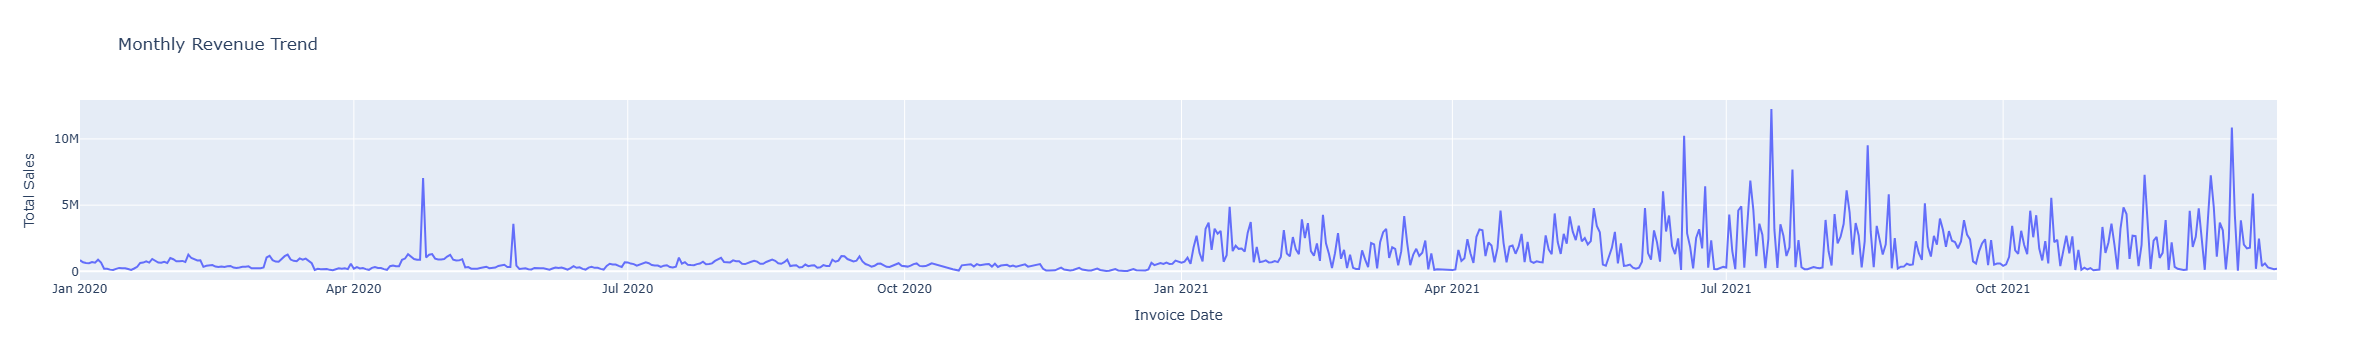

In [21]:
fig = px.line(monthly_sales, x='Invoice Date', y='Total Sales', title='Monthly Revenue Trend')
fig.show()

## Regional Sales Analysis

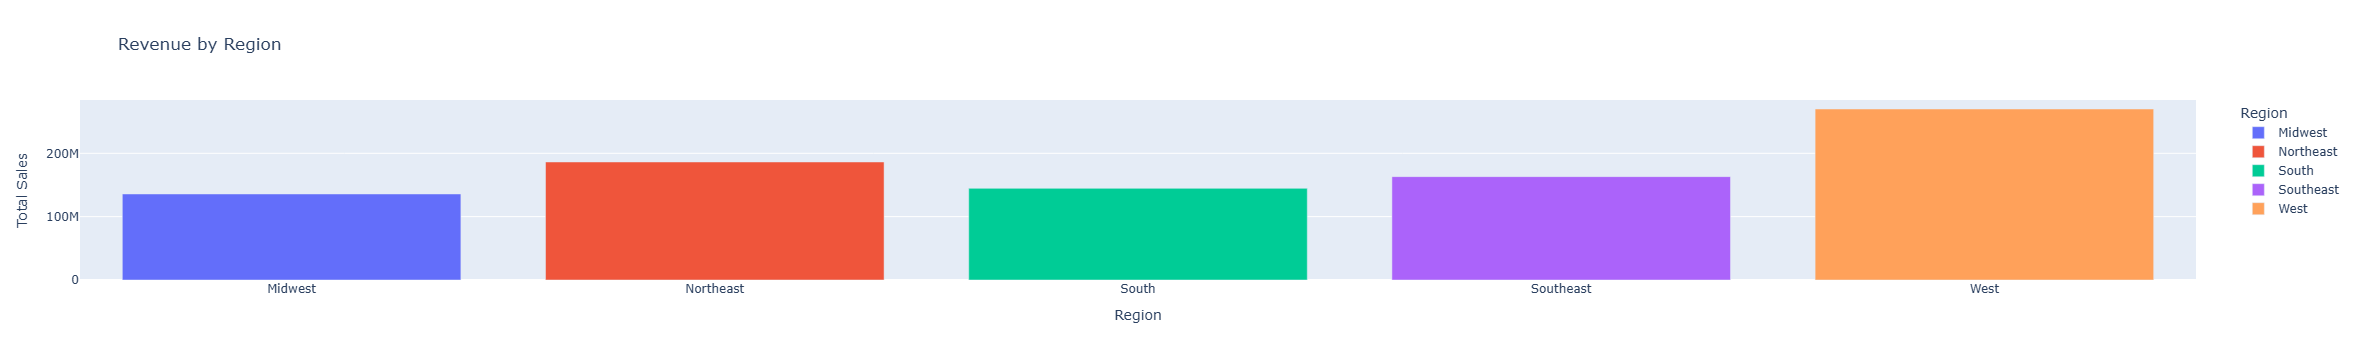

In [22]:
region_sales = (df.groupby('Region')['Total Sales'].sum().reset_index())
fig = px.bar(region_sales, x='Region', y='Total Sales', color='Region', title='Revenue by Region')
fig.show()

## Product Performance

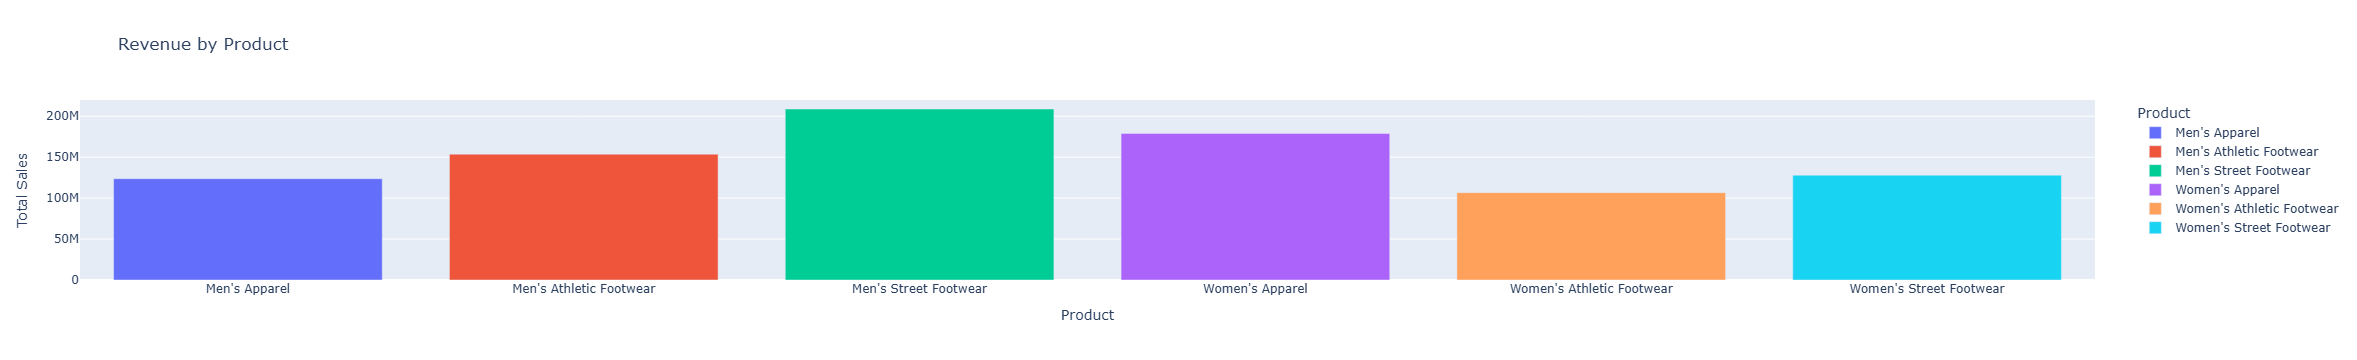

In [23]:
product_sales = (df.groupby('Product')['Total Sales'].sum().reset_index())
fig = px.bar(product_sales, x='Product', y='Total Sales', color='Product', title='Revenue by Product')
fig.show()

## Sales Channel Analysis

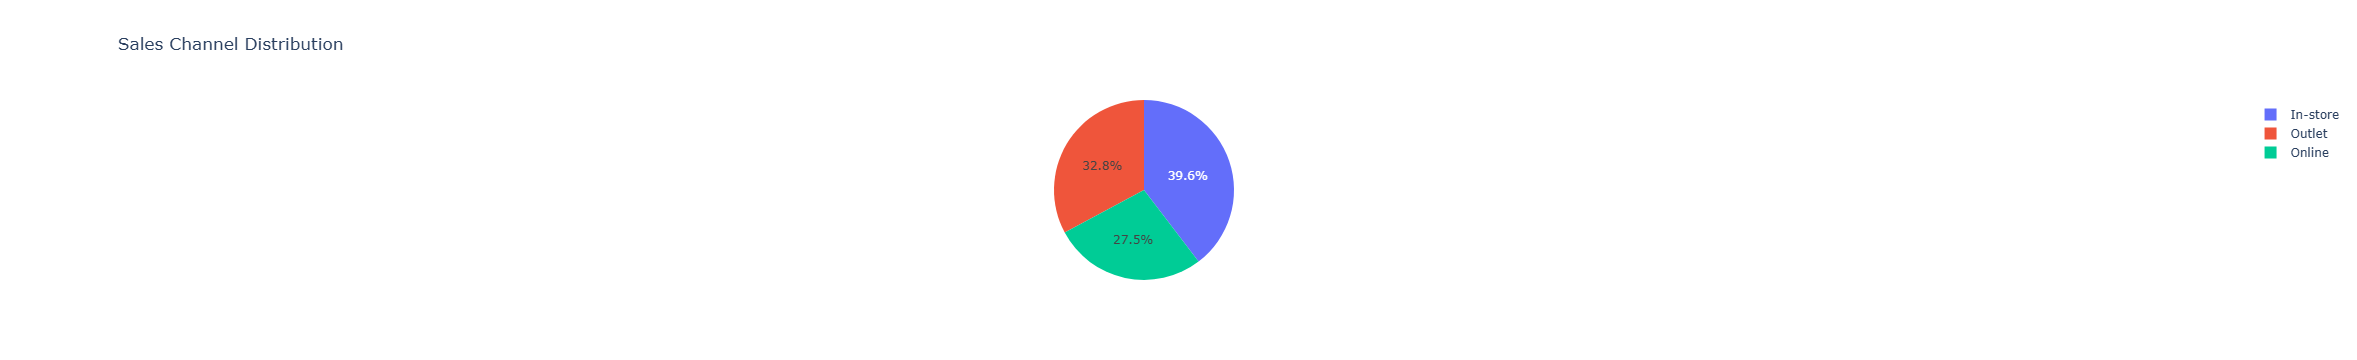

In [24]:
channel_sales = (df.groupby('Sales Method')['Total Sales'].sum().reset_index())
fig = px.pie(channel_sales, names='Sales Method', values='Total Sales', title='Sales Channel Distribution')
fig.show()

## Profit Margin Analysis

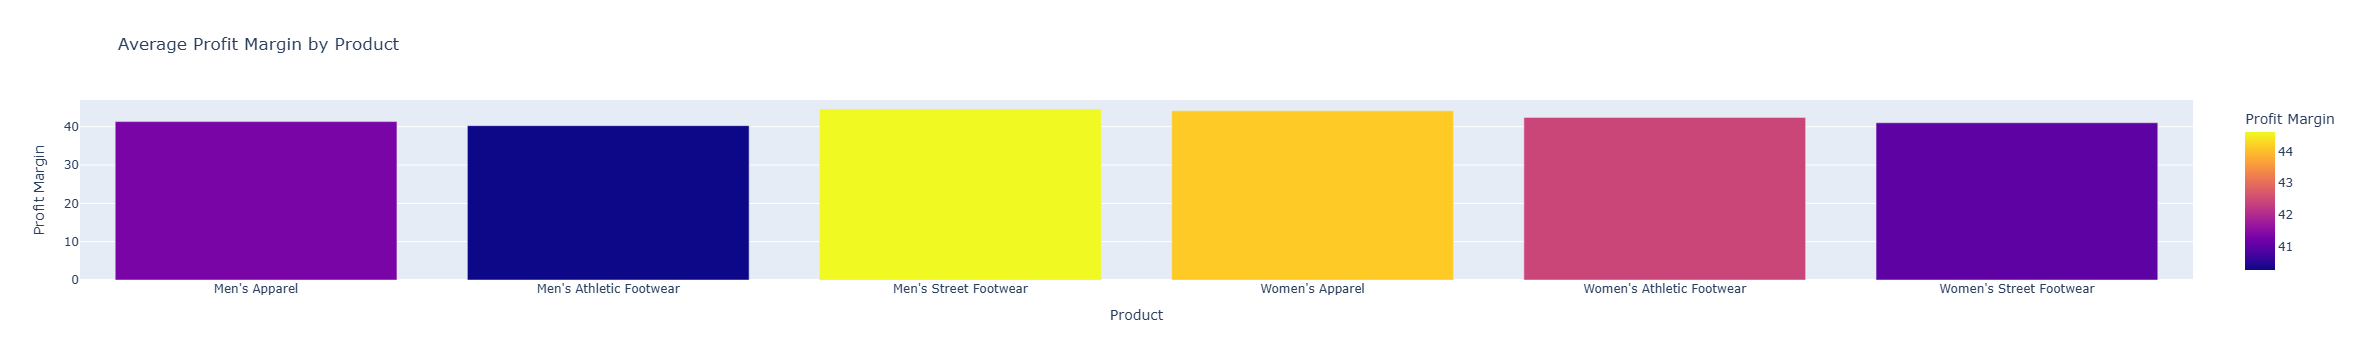

In [25]:
df['Profit Margin'] = (df['Operating Profit'] / df['Total Sales']) * 100
margin_analysis = (df.groupby('Product')['Profit Margin'].mean().reset_index())
fig = px.bar(margin_analysis, x='Product', y='Profit Margin', color='Profit Margin', title='Average Profit Margin by Product')
fig.show()

## HeatMap Analysis

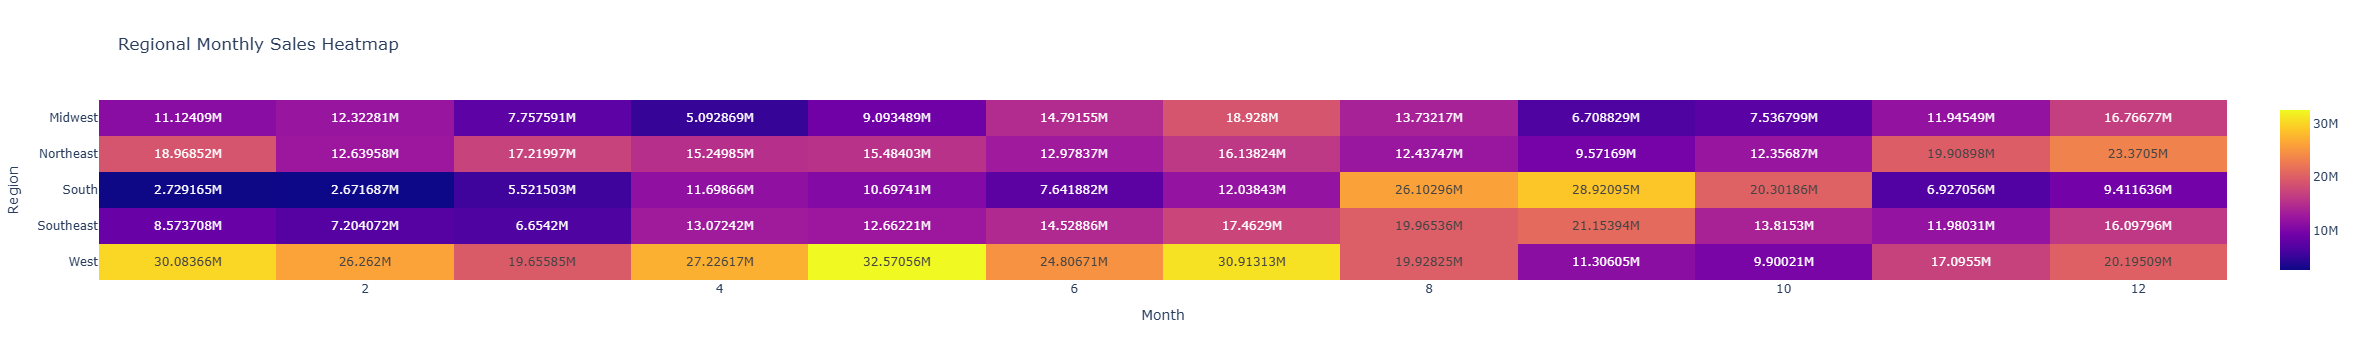

In [26]:
heatmap_data = df.pivot_table(values='Total Sales', index='Region', columns='Month', aggfunc='sum')
fig = px.imshow(heatmap_data, text_auto=True, title='Regional Monthly Sales Heatmap')
fig.show()

## Data Preparation

In [31]:
forecast_df = (monthly_sales.rename(columns={'Invoice Date': 'ds', 'Total Sales': 'y'}))
forecast_df.head()

,ds,y
0,2020-01-01,845141
1,2020-01-02,689410
2,2020-01-03,632573
3,2020-01-04,615080
4,2020-01-05,707829


## Training

In [32]:
model = Prophet()
model.fit(forecast_df)

20:04:59 - cmdstanpy - INFO - Chain [1] start processing
20:04:59 - cmdstanpy - INFO - Chain [1] done processing


## Future Dates

In [33]:
future = model.make_future_dataframe(periods=6, freq='M')
future.tail()

,ds
725,2022-02-28
726,2022-03-31
727,2022-04-30
728,2022-05-31
729,2022-06-30


## Forecast

In [34]:
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,140746.137091,-1.887905e+06,1.540786e+06,140746.137091,140746.137091,-344295.008184,-344295.008184,-344295.008184,-83790.358518,-83790.358518,-83790.358518,-260504.649666,-260504.649666,-260504.649666,0.0,0.0,0.0,-203548.871093
1,2020-01-02,142217.373114,-1.536656e+06,1.616570e+06,142217.373114,142217.373114,-56203.010141,-56203.010141,-56203.010141,158051.150816,158051.150816,158051.150816,-214254.160956,-214254.160956,-214254.160956,0.0,0.0,0.0,86014.362973
2,2020-01-03,143688.609136,-1.470765e+06,1.660148e+06,143688.609136,143688.609136,-950.478199,-950.478199,-950.478199,163798.626480,163798.626480,163798.626480,-164749.104679,-164749.104679,-164749.104679,0.0,0.0,0.0,142738.130937
3,2020-01-04,145159.845159,-1.630697e+06,1.539425e+06,145159.845159,145159.845159,-202784.295659,-202784.295659,-202784.295659,-90336.134715,-90336.134715,-90336.134715,-112448.160944,-112448.160944,-112448.160944,0.0,0.0,0.0,-57624.450500
4,2020-01-05,146631.081182,-1.523524e+06,1.735912e+06,146631.081182,146631.081182,-134084.051309,-134084.051309,-134084.051309,-76217.725478,-76217.725478,-76217.725478,-57866.325831,-57866.325831,-57866.325831,0.0,0.0,0.0,12547.029873


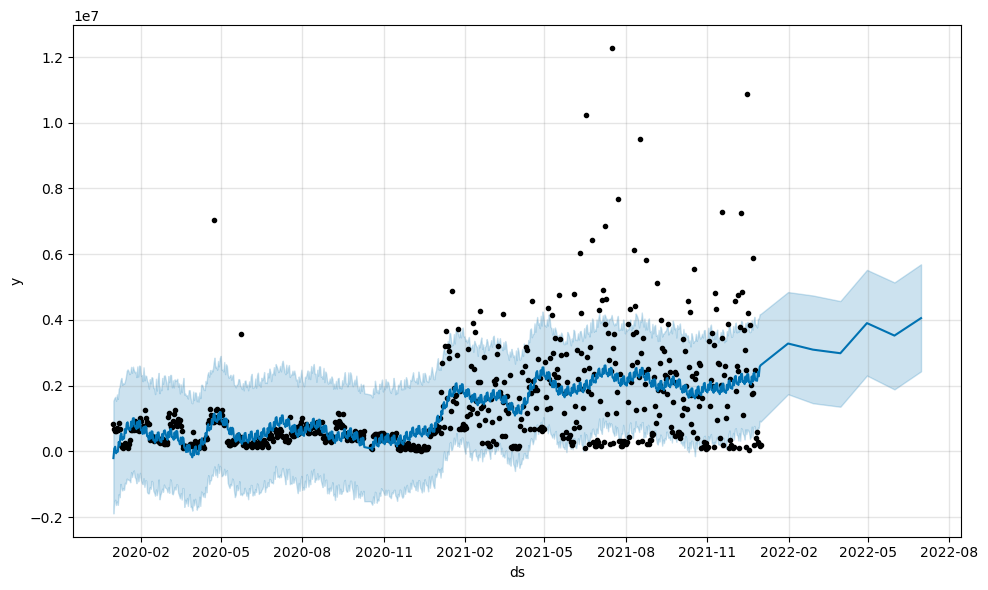

In [35]:
fig1 = model.plot(forecast)

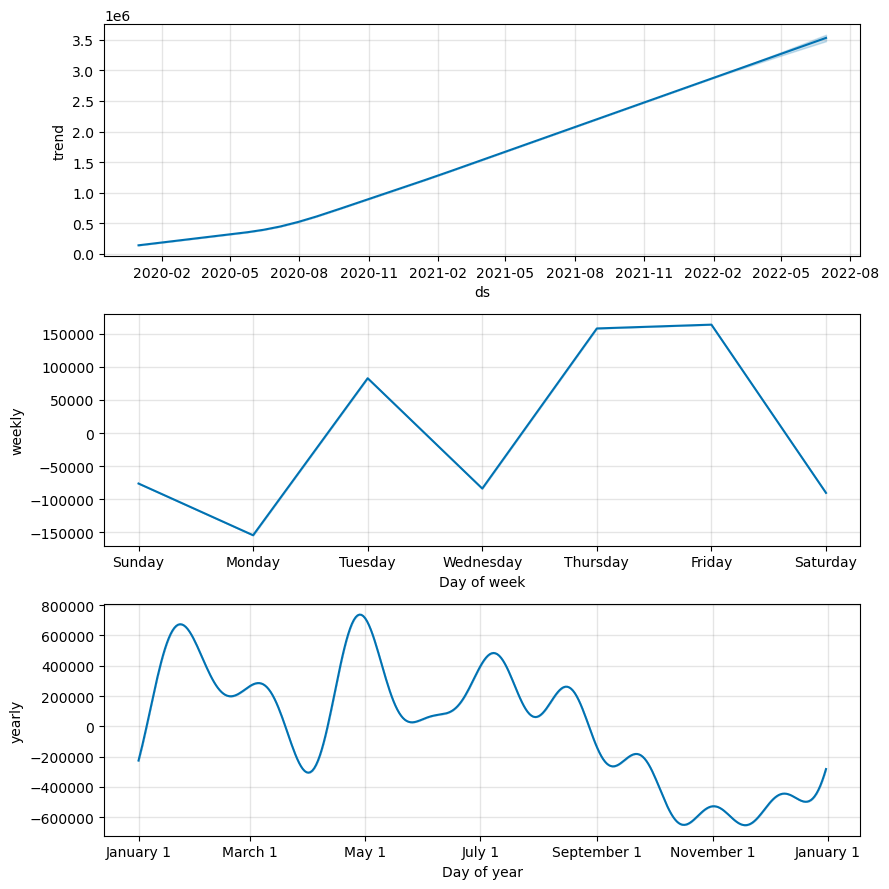

In [36]:
fig2 = model.plot_components(forecast)

## Model Evaluation

In [37]:
actual = forecast_df['y']
predicted = forecast['yhat'][:len(actual)]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
print('MAE:', mae)
print('RMSE:', rmse)

MAE: 778017.146542478
RMSE: 1270222.7526930356


# Business Insights

## Key Findings

1. West region generates the highest revenue.

2. Online sales continue to grow rapidly.

3. Men's Street Footwear is the strongest-performing product category.

4. Significant Q4 demand spikes indicate seasonal purchasing behavior.

5. Forecasting results suggest continued revenue growth over the next periods.

## Recommendations

- Increase inventory allocation before Q4.
- Expand online sales operations.
- Focus marketing on high-margin products.
- Use forecasting models for supply chain planning.

In [38]:
df.to_csv(
    "cleaned_adidas_sales.csv",
    index=False
)

print("Cleaned dataset saved.")

Cleaned dataset saved.
